In [43]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import functools

In [44]:
class Distribution:  # abstract
    def __init__(self, *args, **kwargs):
        self._dist = Counter()
        self._generate_dist(*args, **kwargs)
        self._build_ranks()
    
    def _generate_dist(self, *args, **kwargs):
        # should be implemented by subclasses
        pass
    
    def _build_ranks(self):
        self._ranks = [0] * 101
        cur_rank = 0
        last_count = 1
        for i in range(100, -1, -1):
            if self._dist[i] != 0:
                cur_rank += last_count
                last_count = self._dist[i]
            self._ranks[i] = cur_rank
        self.max_rank = cur_rank

    def __add__(self, other):
        result = Distribution()
        result._dist = self._dist + other._dist
        result._build_ranks()
        return result

    @property
    def size(self):
        return sum(self._dist.values())

    def get_multiplier(self, value):
        return 0.9 - 0.8 * (self._ranks[value] - 1) / (self.max_rank - 1)


class RandomDist(Distribution):
    def _generate_dist(self, low, high, n):
        self.samples = []
        for i in range(n):
            sample = np.random.randint(low, high + 1)
            self._dist[sample] += 1
            self.samples.append(sample)


class NormalDist(Distribution):
    def _generate_dist(self, mean, std, n):
        self.samples = []
        for i in range(n):
            sample = int(np.random.normal(mean, std))
            sample = max(0, min(100, sample))
            self._dist[sample] += 1
            self.samples.append(sample)


class FixedDist(Distribution):
    def _generate_dist(self, val, n):
        assert val >= 0 and val <= 100
        self._dist[val] = n


class AllDist(Distribution):
    def _generate_dist(self, n):
        for i in range(101):
            self._dist[i] = n


test_fixed_dist1 = FixedDist(50, 10)
test_fixed_dist2 = FixedDist(70, 20)
test_fixed_dist3 = test_fixed_dist1 + test_fixed_dist2
assert test_fixed_dist3._ranks[70] == 1
assert test_fixed_dist3._ranks[50] == 21
assert abs(test_fixed_dist3.get_multiplier(70) - 0.9) < 1e-10
assert abs(test_fixed_dist3.get_multiplier(50) - 0.1) < 1e-10
assert test_fixed_dist3.size == 30

test_random_dist = RandomDist(20, 50, 100)
actual = [(i, test_random_dist.get_multiplier(i)) for i in sorted(set(test_random_dist.samples), reverse=True)]
for i in range(len(actual) - 1):
    assert (actual[i + 1][1] - actual[i][1]) / (0.8 / 99) - test_random_dist._dist[actual[i][0]] < 1e-6

In [45]:
def _get_pnl_without_speed(research: int, scale: int) -> float:
    return (200_000 * np.log(1 + research) / np.log(1 + 100)) * (scale * 7 / 100)

def get_pnl(research: int, scale: int, speed: int, dist: Distribution) -> float:
    assert research >= 0 and research <= 100
    assert scale >= 0 and scale <= 100
    assert speed >= 0 and speed <= 100
    assert research + scale + speed <= 100

    return _get_pnl_without_speed(research, scale) * dist.get_multiplier(speed) \
        - (research + scale + speed) / 100 * 50_000

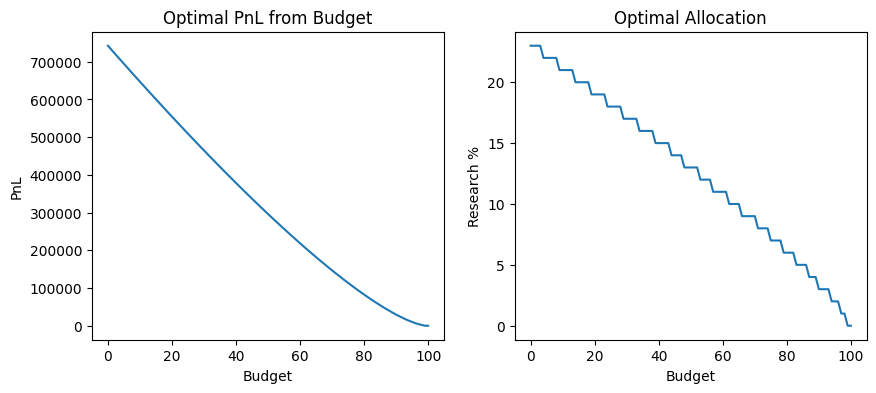

In [46]:
# optimal allocation if not taking into account speed
# here budget = research + scale
@functools.cache
def get_optimal_without_speed(budget_left: int) -> tuple[int, tuple[int, int]]:
    assert budget_left >= 0 and budget_left <= 100
    max_allocation = None
    max_pnl = -1
    for i in range(budget_left + 1):
        pnl = _get_pnl_without_speed(i, budget_left - i)
        if max_pnl < pnl:
            max_allocation = (i, budget_left - i)
            max_pnl = pnl
    return max_pnl, max_allocation


interval = range(0, 101, 1)
optimal_alloc = [get_optimal_without_speed(100 - i) for i in interval]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes.flatten()

axes[0].plot(interval, [t[0] for t in optimal_alloc])
axes[0].set_title("Optimal PnL from Budget")
axes[0].set_xlabel("Budget")
axes[0].set_ylabel("PnL")

axes[1].plot(interval, [t[1][0] for t in optimal_alloc])
axes[1].set_title("Optimal Allocation")
axes[1].set_xlabel("Budget")
axes[1].set_ylabel("Research %")

plt.show()

In [47]:
def draw(*args: Distribution):
    interval = range(0, 101, 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes.flatten()

    axes[0].set_title("Speed Distribution")
    axes[0].set_xlabel("Speed")
    axes[0].set_ylabel("Probability")
    axes[0].set_ylim(bottom=0)

    axes[1].set_title("PnL Given Speed Distribution")
    axes[1].set_xlabel("Speed")
    axes[1].set_ylabel("PnL")

    for dist in args:
        pnls = [get_pnl(*optimal_alloc[s][1], s, dist) for s in interval]
        sorted_pnls = sorted([(p, s) for s, p in zip(interval, pnls)], reverse=True)
        print("Top 5 PnL with Speed Distribution:")
        for p, s in sorted_pnls[:5]:
            print(f"Speed: {s}, PnL: {p}")
        axes[0].plot(interval, [dist._dist[i] / dist.size for i in interval])
        axes[1].plot(interval, pnls)

Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 110065.31395662151
Speed: 35, PnL: 110030.93566754149
Speed: 37, PnL: 109962.17908938142
Speed: 34, PnL: 109859.04422214135
Speed: 38, PnL: 109721.53106582124


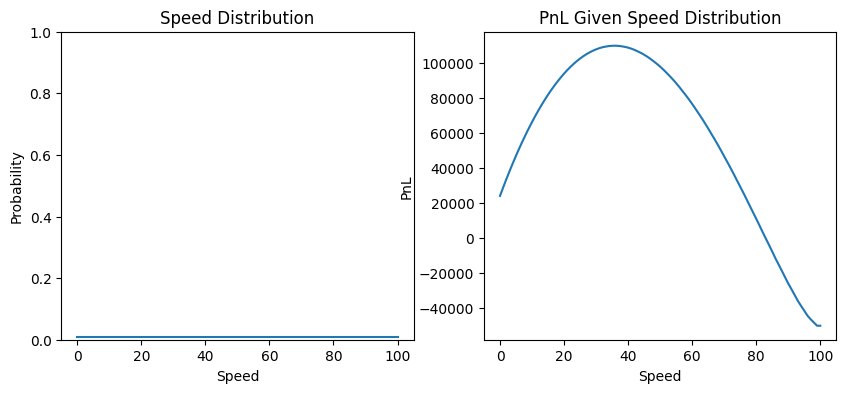

In [48]:
dist = AllDist(10)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 121406.12012095173
Speed: 36, PnL: 121327.18168880799
Speed: 34, PnL: 120802.97373475082
Speed: 35, PnL: 120800.36140275386
Speed: 37, PnL: 119722.33906534052


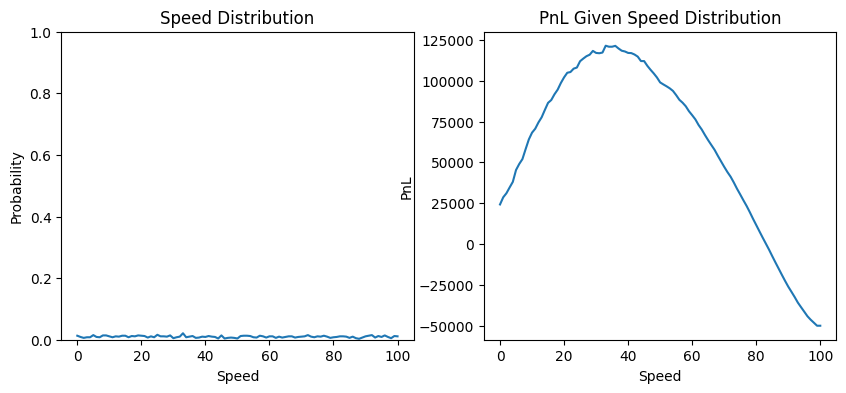

In [49]:
dist = RandomDist(0, 100, 1000)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 37, PnL: 260830.10630523856
Speed: 38, PnL: 260586.8963547983
Speed: 35, PnL: 259467.78437643778
Speed: 34, PnL: 259205.53307756444
Speed: 36, PnL: 259134.56077885942


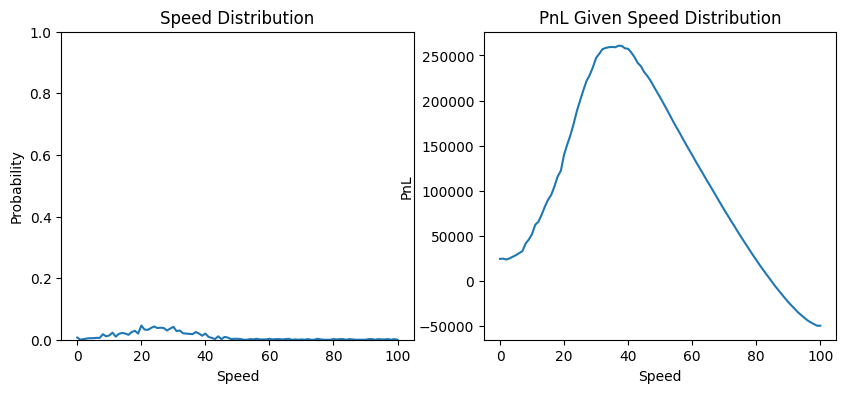

In [50]:
dist = RandomDist(0, 100, 100) + NormalDist(25, 10, 900)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 22, PnL: 378718.1914624175
Speed: 23, PnL: 376532.06408680364
Speed: 24, PnL: 375054.443583896
Speed: 21, PnL: 374597.76106664445
Speed: 25, PnL: 370588.45558229304


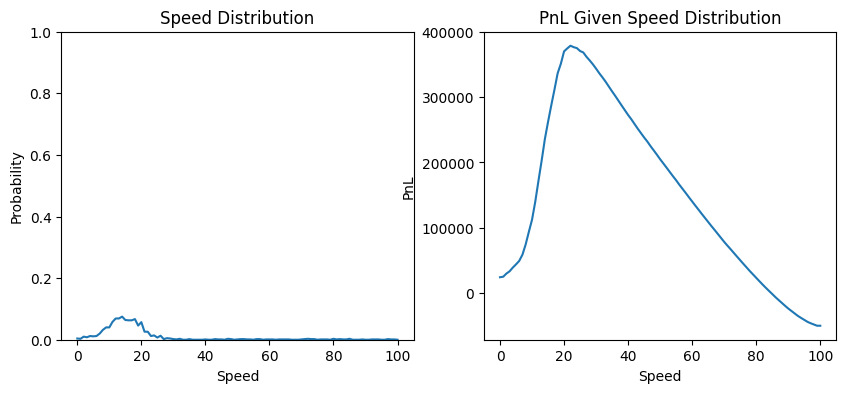

In [51]:
dist = RandomDist(0, 100, 100) + NormalDist(15, 5, 900)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 44, PnL: 195120.41112211125
Speed: 46, PnL: 194533.16202819571
Speed: 47, PnL: 193823.84430239888
Speed: 45, PnL: 193612.69856076632
Speed: 43, PnL: 192450.14468693695


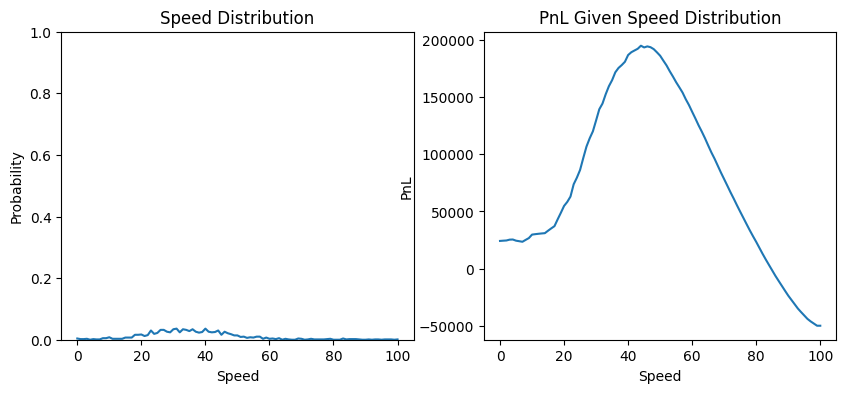

In [52]:
dist = RandomDist(0, 100, 100) + NormalDist(35, 12, 900)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 265173.5138113692
Speed: 37, PnL: 264784.42351745535
Speed: 35, PnL: 263605.04760434764
Speed: 38, PnL: 263496.1023220518
Speed: 34, PnL: 261704.55767985305
Top 5 PnL with Speed Distribution:
Speed: 22, PnL: 374528.1402005768
Speed: 23, PnL: 374092.8836231476
Speed: 24, PnL: 373891.17539543967
Speed: 21, PnL: 372544.8999795711
Speed: 25, PnL: 369847.6215294593
Top 5 PnL with Speed Distribution:
Speed: 47, PnL: 193611.42125609808
Speed: 45, PnL: 193402.1352171172
Speed: 44, PnL: 193248.0545506234
Speed: 46, PnL: 193002.51423717337
Speed: 48, PnL: 192415.46932318693


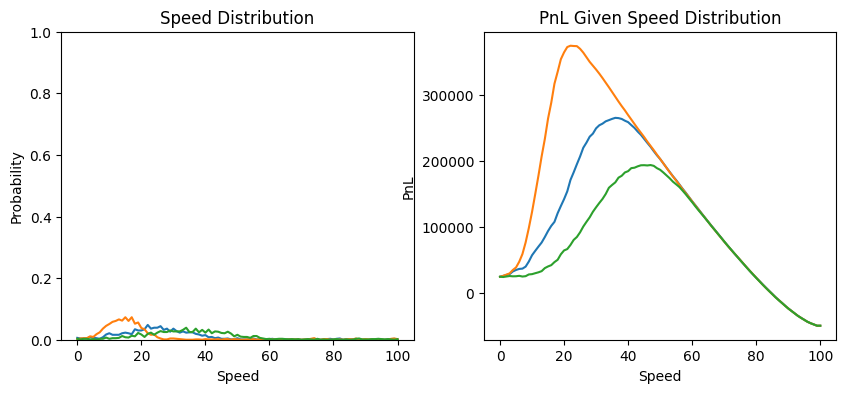

In [53]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(25, 10, 900),
    RandomDist(0, 100, 100) + NormalDist(15, 5, 900),
    RandomDist(0, 100, 100) + NormalDist(35, 12, 900)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 32, PnL: 310152.414719207
Speed: 33, PnL: 308361.92293460114
Speed: 34, PnL: 307131.1743859871
Speed: 31, PnL: 306615.3588189013
Speed: 30, PnL: 304533.18731276
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 289563.11082805577
Speed: 33, PnL: 287979.4845622482
Speed: 35, PnL: 287498.00218041264
Speed: 32, PnL: 286853.1791315002
Speed: 36, PnL: 286232.06818873814
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 276877.6510499887
Speed: 33, PnL: 276801.89353533316
Speed: 35, PnL: 276073.25414583884
Speed: 36, PnL: 275695.57474378345
Speed: 37, PnL: 274085.9206179392
Top 5 PnL with Speed Distribution:
Speed: 37, PnL: 256464.9962403085
Speed: 35, PnL: 256166.58571073064
Speed: 38, PnL: 255403.10847862333
Speed: 36, PnL: 254944.14959395083
Speed: 34, PnL: 254038.44746031956
Top 5 PnL with Speed Distribution:
Speed: 37, PnL: 250462.85513946292
Speed: 36, PnL: 250344.15543936827
Speed: 35, PnL: 249954.1421390575
Speed: 38, PnL: 248996.5122277679

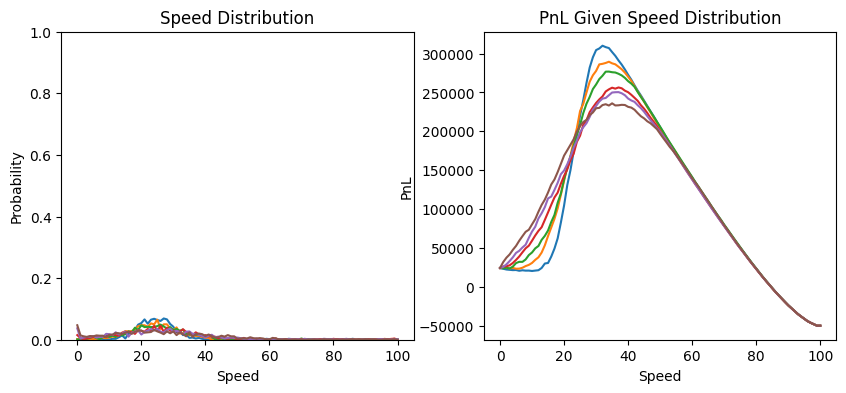

In [54]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(25, std, 900)
    for std in range(5, 16, 2)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 18, PnL: 419904.08264091687
Speed: 19, PnL: 419599.9604298433
Speed: 17, PnL: 413957.40566456784
Speed: 20, PnL: 413358.85461038805
Speed: 21, PnL: 407074.0410174673
Top 5 PnL with Speed Distribution:
Speed: 20, PnL: 404027.2449754629
Speed: 19, PnL: 401985.7277231697
Speed: 21, PnL: 399643.71952829976
Speed: 22, PnL: 395588.0023821291
Speed: 18, PnL: 391904.9138584056
Top 5 PnL with Speed Distribution:
Speed: 21, PnL: 389205.4806960228
Speed: 22, PnL: 388325.8325873424
Speed: 20, PnL: 385427.6331310283
Speed: 23, PnL: 384695.3510963979
Speed: 24, PnL: 380156.4539441918
Top 5 PnL with Speed Distribution:
Speed: 21, PnL: 381286.4546727094
Speed: 23, PnL: 380430.51077567285
Speed: 22, PnL: 379685.6574695284
Speed: 20, PnL: 379142.95261566265
Speed: 24, PnL: 378043.9177456277
Top 5 PnL with Speed Distribution:
Speed: 24, PnL: 357941.7866079667
Speed: 25, PnL: 355443.003037839
Speed: 23, PnL: 354805.45718366094
Speed: 21, PnL: 354636.21490428655
Sp

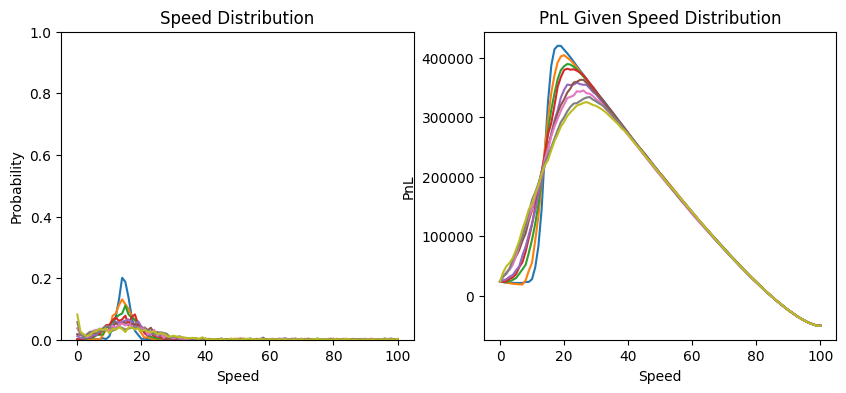

In [55]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(15, std, 900)
    for std in range(2, 11, 1)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 32, PnL: 312303.11338884145
Speed: 33, PnL: 311876.1364470758
Speed: 34, PnL: 308164.5898893949
Speed: 31, PnL: 306249.8806136039
Speed: 35, PnL: 303364.37487606594
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 288922.096673623
Speed: 35, PnL: 287876.81085700047
Speed: 33, PnL: 285578.6329884105
Speed: 36, PnL: 284945.70898273453
Speed: 32, PnL: 282979.8404363543
Top 5 PnL with Speed Distribution:
Speed: 35, PnL: 274953.2777517808
Speed: 37, PnL: 274006.7541457158
Speed: 36, PnL: 272955.92329344497
Speed: 34, PnL: 271585.2743557006
Speed: 38, PnL: 271554.24079484603
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 257234.2551874434
Speed: 35, PnL: 256874.84580160666
Speed: 37, PnL: 256100.46615869284
Speed: 36, PnL: 255612.5722581126
Speed: 33, PnL: 254930.25881826458
Top 5 PnL with Speed Distribution:
Speed: 35, PnL: 242705.56088821747
Speed: 39, PnL: 242246.35197750188
Speed: 34, PnL: 241931.3390886879
Speed: 36, PnL: 241505.1619513320

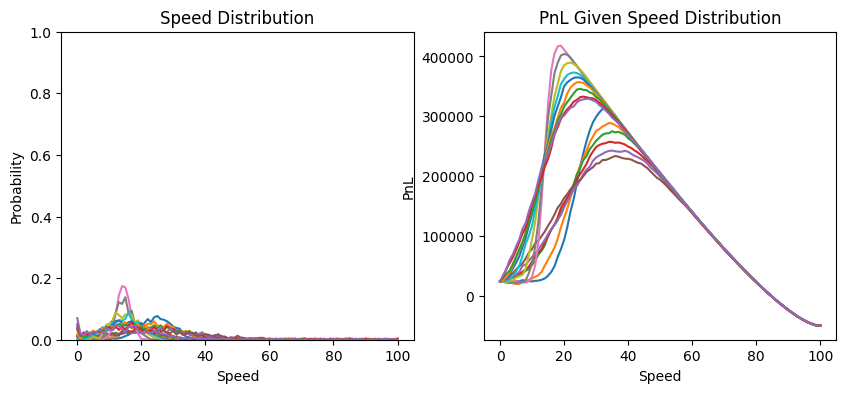

In [56]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(25, std, 900)
    for std in range(5, 16, 2)
] + [
    RandomDist(0, 100, 100) + NormalDist(15, std, 900)
    for std in range(2, 11, 1)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 167957.46900674797
Speed: 35, PnL: 167062.66135395798
Speed: 30, PnL: 166582.2028764621
Speed: 36, PnL: 166450.65710748182
Speed: 31, PnL: 166246.36060285545
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 164143.08390235718
Speed: 35, PnL: 162216.21686056384
Speed: 39, PnL: 160977.17202429014
Speed: 32, PnL: 160324.4180282281
Speed: 36, PnL: 160193.18677239286
Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 170154.70410367084
Speed: 35, PnL: 169747.05421148855
Speed: 34, PnL: 169547.99736054832
Speed: 32, PnL: 169196.67874994787
Speed: 31, PnL: 168525.34427514448
Top 5 PnL with Speed Distribution:
Speed: 31, PnL: 182568.7554737839
Speed: 32, PnL: 181896.89432029636
Speed: 30, PnL: 180129.32892862547
Speed: 35, PnL: 180029.78905451807
Speed: 34, PnL: 179245.66273984415
Top 5 PnL with Speed Distribution:
Speed: 31, PnL: 171462.29097698882
Speed: 30, PnL: 171301.29403944672
Speed: 29, PnL: 170973.5089076164
Speed: 32, PnL: 170511.3

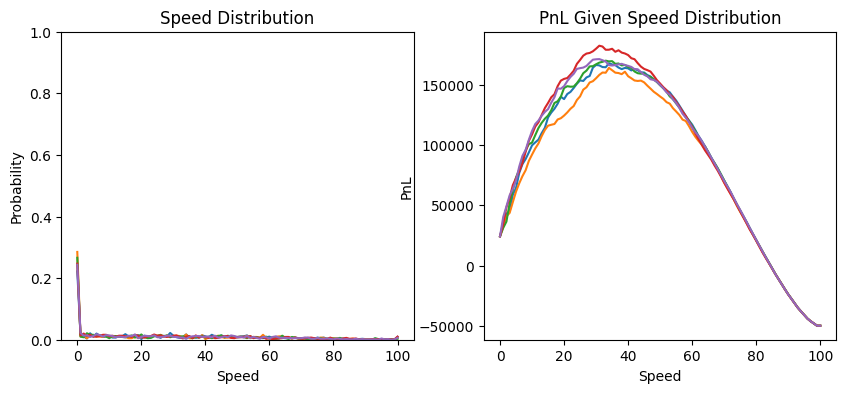

In [57]:
dist = [
    NormalDist(0, 10, 150) + NormalDist(20, 30, 600) + NormalDist(50, 25, 250)
    for _ in range(5)
]
draw(*dist)

Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 245598.5210851021
Speed: 33, PnL: 245073.93531102268
Speed: 31, PnL: 244506.22549503268
Speed: 30, PnL: 244438.6409931291
Speed: 35, PnL: 243841.62445149
Top 5 PnL with Speed Distribution:
Speed: 31, PnL: 241368.9040826045
Speed: 32, PnL: 241252.3565209714
Speed: 33, PnL: 239844.82058432623
Speed: 30, PnL: 238229.29207615124
Speed: 34, PnL: 237276.65389217634
Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 240096.61690675834
Speed: 32, PnL: 240040.07835497148
Speed: 34, PnL: 239989.8412290691
Speed: 35, PnL: 237638.4295936821
Speed: 31, PnL: 237140.4583418988
Top 5 PnL with Speed Distribution:
Speed: 32, PnL: 238575.46063249093
Speed: 33, PnL: 237942.7673148752
Speed: 31, PnL: 237887.12620041828
Speed: 34, PnL: 237526.70895107306
Speed: 30, PnL: 237335.20224249823
Top 5 PnL with Speed Distribution:
Speed: 31, PnL: 242224.9471096379
Speed: 33, PnL: 242057.0879456703
Speed: 34, PnL: 241182.70817021676
Speed: 35, PnL: 240505.2948365114

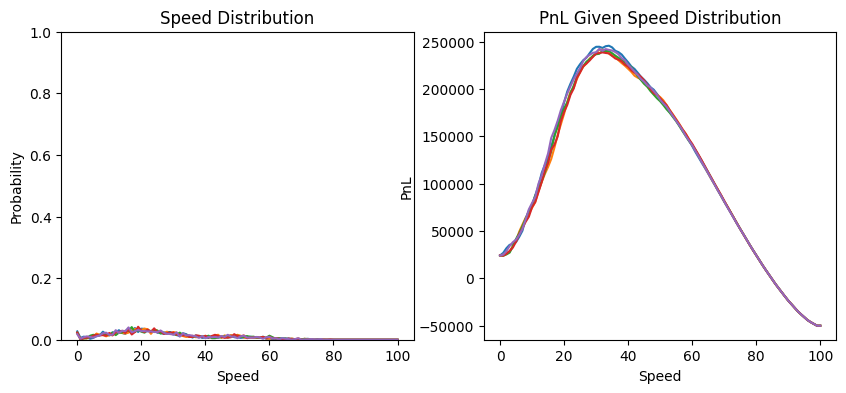

In [58]:
dist = [
    NormalDist(20, 10, 750) + NormalDist(50, 10, 250)
    for _ in range(5)
]
draw(*dist)

Top 5 PnL with Speed Distribution:
Speed: 44, PnL: 158756.31959980092
Speed: 47, PnL: 158626.8779912953
Speed: 45, PnL: 158503.35854788465
Speed: 48, PnL: 158456.390093669
Speed: 46, PnL: 158291.0066280486
Top 5 PnL with Speed Distribution:
Speed: 44, PnL: 168989.82088401244
Speed: 43, PnL: 168388.03741527404
Speed: 42, PnL: 167926.36022235322
Speed: 45, PnL: 167383.22209608936
Speed: 46, PnL: 165871.37794968675
Top 5 PnL with Speed Distribution:
Speed: 46, PnL: 164350.1070575181
Speed: 47, PnL: 164281.43770665728
Speed: 48, PnL: 161657.61875204893
Speed: 44, PnL: 161394.78166121015
Speed: 45, PnL: 161088.7367765093
Top 5 PnL with Speed Distribution:
Speed: 43, PnL: 160447.96343011546
Speed: 44, PnL: 160411.82556460428
Speed: 42, PnL: 160361.67783021985
Speed: 40, PnL: 159791.6699278795
Speed: 41, PnL: 159731.5314794675
Top 5 PnL with Speed Distribution:
Speed: 46, PnL: 164788.4677608813
Speed: 45, PnL: 164608.26473727537
Speed: 47, PnL: 163642.10580320054
Speed: 43, PnL: 163149.343864

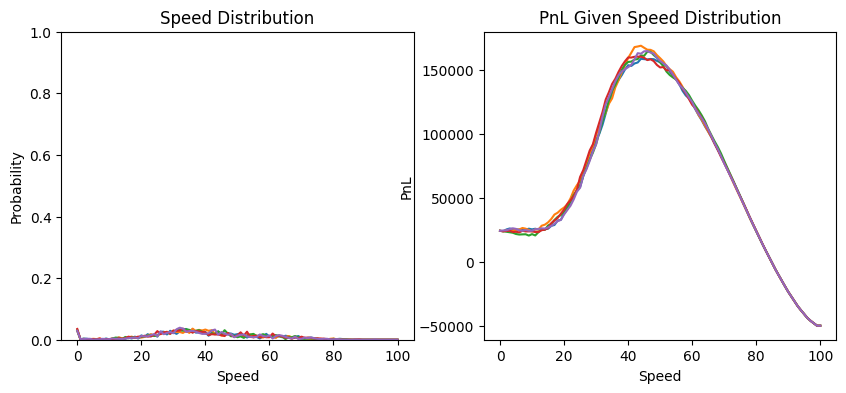

In [59]:
dist = [
    NormalDist(0, 10, 50) + NormalDist(35, 10, 700) + NormalDist(60, 10, 250)
    for _ in range(5)
]
draw(*dist)

Top 5 PnL with Speed Distribution:
Speed: 55, PnL: 112338.2131957256
Speed: 53, PnL: 112142.29971195073
Speed: 54, PnL: 112058.67810302248
Speed: 56, PnL: 110884.78999292443
Speed: 52, PnL: 110402.8623574574
Top 5 PnL with Speed Distribution:
Speed: 56, PnL: 111174.45537734602
Speed: 57, PnL: 110512.47529602575
Speed: 55, PnL: 110505.24325930196
Speed: 53, PnL: 108801.79423155347
Speed: 58, PnL: 108573.69404486584
Top 5 PnL with Speed Distribution:
Speed: 53, PnL: 113034.26354051914
Speed: 55, PnL: 112968.95904592754
Speed: 54, PnL: 112925.15725077462
Speed: 52, PnL: 112008.89852624293
Speed: 56, PnL: 111496.42233251416
Top 5 PnL with Speed Distribution:
Speed: 56, PnL: 111572.3274741453
Speed: 52, PnL: 111134.22652047357
Speed: 57, PnL: 111082.41255667439
Speed: 54, PnL: 111034.45531555131
Speed: 53, PnL: 110854.89858605035
Top 5 PnL with Speed Distribution:
Speed: 54, PnL: 114573.73846585807
Speed: 55, PnL: 113955.59335631537
Speed: 52, PnL: 113711.61283762168
Speed: 56, PnL: 113490.

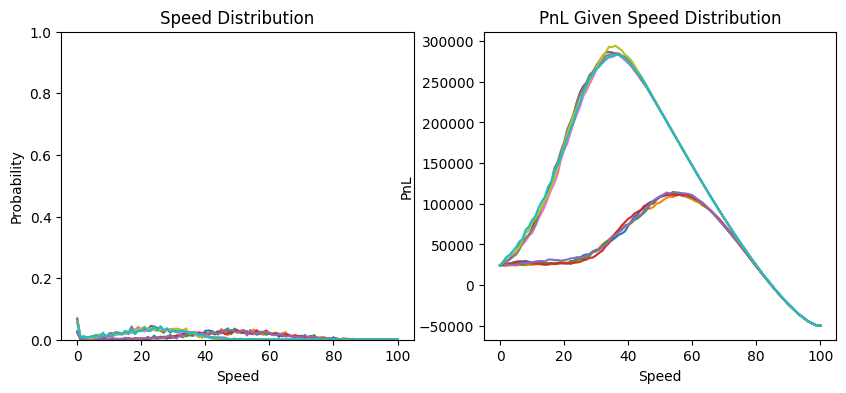

In [60]:
dist = [
    NormalDist(0, 10, 50) + NormalDist(50, 15, 950)
    for _ in range(5)
] + [
    NormalDist(0, 10, 100) + NormalDist(25, 10, 900)
    for _ in range(5)
]
draw(*dist)

In [61]:
print(optimal_alloc[35])

(np.float64(421134.0412303723), (16, 49))
